In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_gridsearch_refined_fine"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")


Found 180 result files

Total loaded: 180 results


In [14]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
        
        # Extract cluster parameters
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
        else:
            cluster_f = None
            n_subtypes = 0
        
        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan
        
        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []
        
        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("final_lse").reset_index(drop=True)
print("\n=== Summary Statistics (sorted by LSE) ===")
print(summary_df[["candidate", "final_lse", "n_subtypes", "scalar_K", "mean_s"]].head(10))

# Find best model (lowest LSE)
best_row = summary_df.iloc[0]
best_key = best_row["key"]
best_data = results[best_key]

print(f"Key: {best_key}")
print(f"Final LSE: {best_row['final_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")



=== Summary Statistics (sorted by LSE) ===
  candidate   final_lse  n_subtypes              scalar_K    mean_s
0       103  611.743849           2   0.04325942507541538  0.949596
1        23  694.417638           2  0.030131337810075296  0.907538
2         3  699.863852           2  0.037723024643891365  0.924450
3         7  703.962317           2   0.03673380232781289  0.929452
4        11  707.294226           2  0.018134616890483776  0.850091
5         0  720.967400           2   0.13590192707502136  0.497770
6         5  722.113326           2   0.13336706490728228  0.498595
7         9  722.302897           2   0.13256054764192648  0.498473
8        50  723.562684           2   0.14310095798749373  0.498293
9        12  726.570777           2    0.1451979842385529  0.494489
Key: PPMI_subtyping_grid_103_lambda_f0p300_lambda_cog0p100_lambda_scalar0p500_lambda_jsd0p100_lambda_beta1p000
Final LSE: 611.743849

Parameters:
  lambda_f: 0.3
  lambda_cog: 0.1
  lambda_scalar: 0.5
  lambd

In [15]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [16]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

print(f"Valid patients: {len(np.unique(ids_valid))}")
print(f"Subtype 0: {np.sum(assignment_valid == 0)} patients")
print(f"Subtype 1: {np.sum(assignment_valid == 1)} patients")


Valid patients: 146
Subtype 0: 286 patients
Subtype 1: 218 patients



All subgroup types found: ['GBA' 'LRRK2' 'PRKN' 'Sporadic PD']

=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===
Clinical Subgroup   GBA  LRRK2  PRKN  Sporadic PD
Discovered Subtype                               
0                     2      1     2           78
1                     4      0     3           56

Chi-square test:
  χ² = 2.7913
  p-value = 0.4249
  df = 3


<Figure size 1200x600 with 0 Axes>

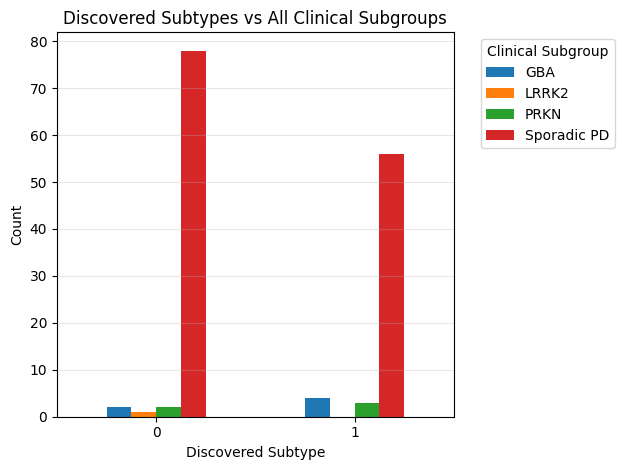

Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 5           78
1                                 7           56

Chi-square test (binary):
  χ² = 0.6468
  p-value = 0.4213
  df = 1


<Figure size 1000x600 with 0 Axes>

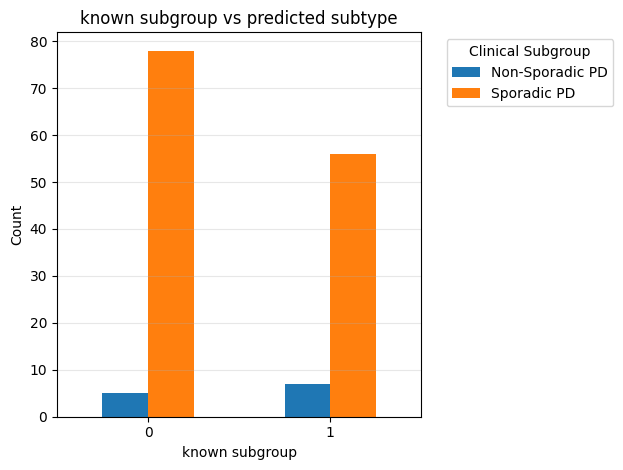

In [17]:
# Clinical Subgroup Comparison: All Subgroup Types
# Get unique patient IDs and their subgroup assignments
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            # Take most common subgroup if multiple
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Get all unique subgroup types
all_subgroups = np.unique(subgroup_per_patient)
print(f"\nAll subgroup types found: {all_subgroups}")

# Create contingency table with all subgroup types
contingency_all = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(subgroup_per_patient, name='Clinical Subgroup')
)
print("\n=== Contingency Table: Discovered Subtypes vs All Clinical Subgroups ===")
print(contingency_all)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_all)
print(f"\nChi-square test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot all subgroups
plt.figure(figsize=(12, 6))
contingency_all.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs All Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Also create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup_binary = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table for binary
contingency_binary = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup_binary, name='Clinical Subgroup')
)
print(contingency_binary)

# Chi-square test for binary
chi2_binary, p_value_binary, dof_binary, expected_binary = chi2_contingency(contingency_binary)
print(f"\nChi-square test (binary):")
print(f"  χ² = {chi2_binary:.4f}")
print(f"  p-value = {p_value_binary:.4f}")
print(f"  df = {dof_binary}")

# Plot binary
plt.figure(figsize=(10, 6))
contingency_binary.plot(kind='bar', stacked=False)
plt.title('known subgroup vs predicted subtype')
plt.xlabel('known subgroup')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


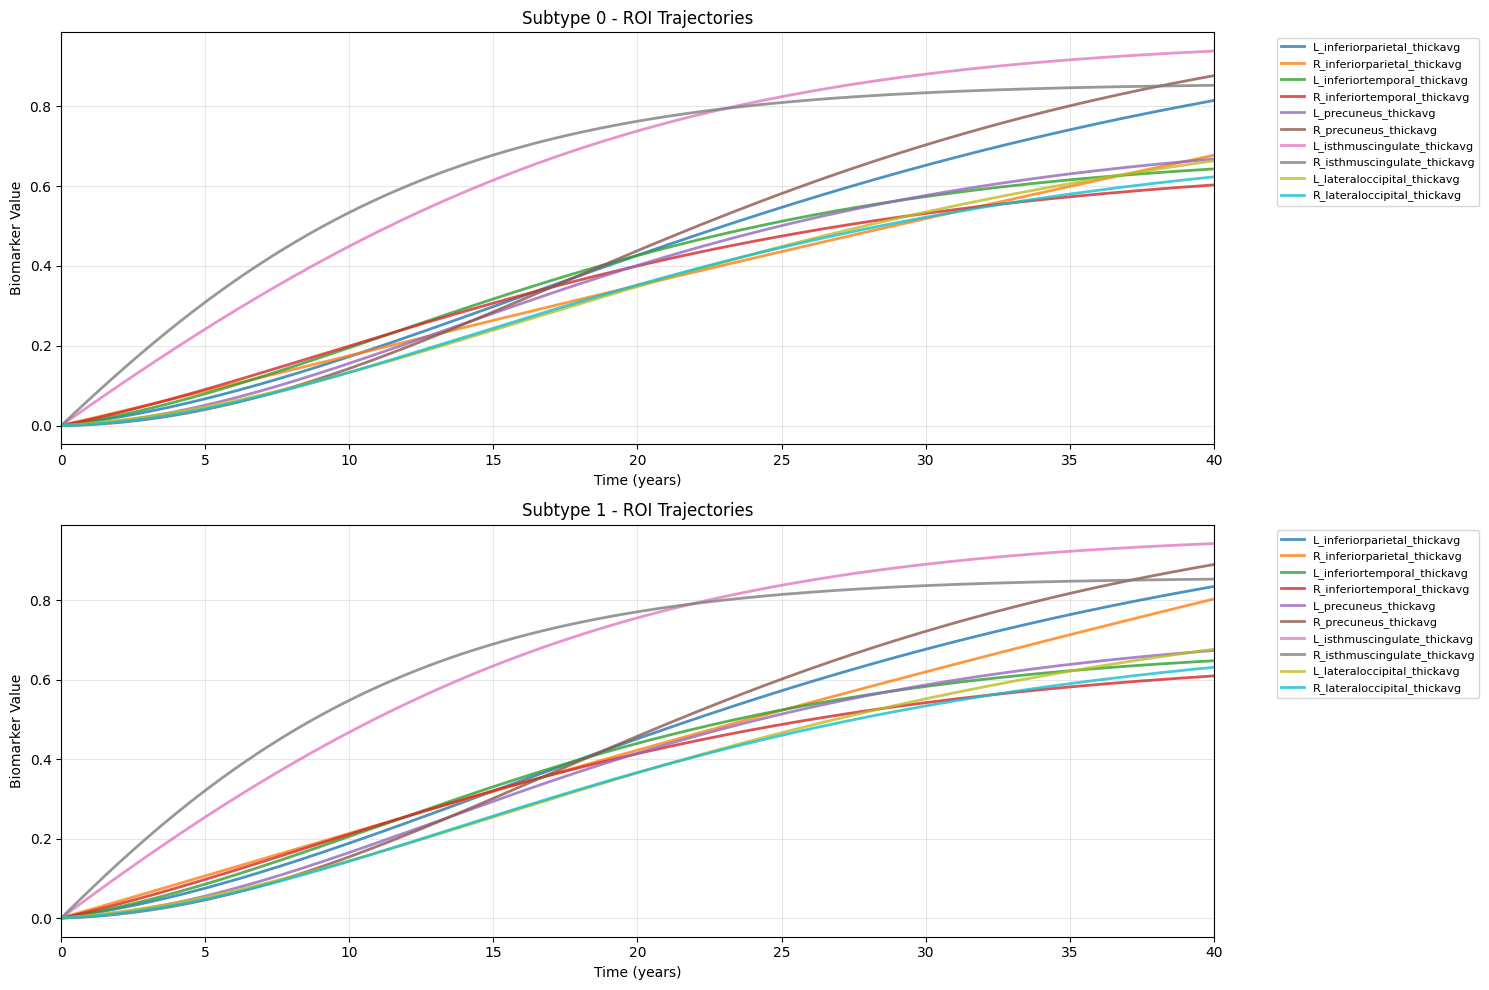

In [18]:
# ROI Subplots: 10 ROI trajectories for each subtype
ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()


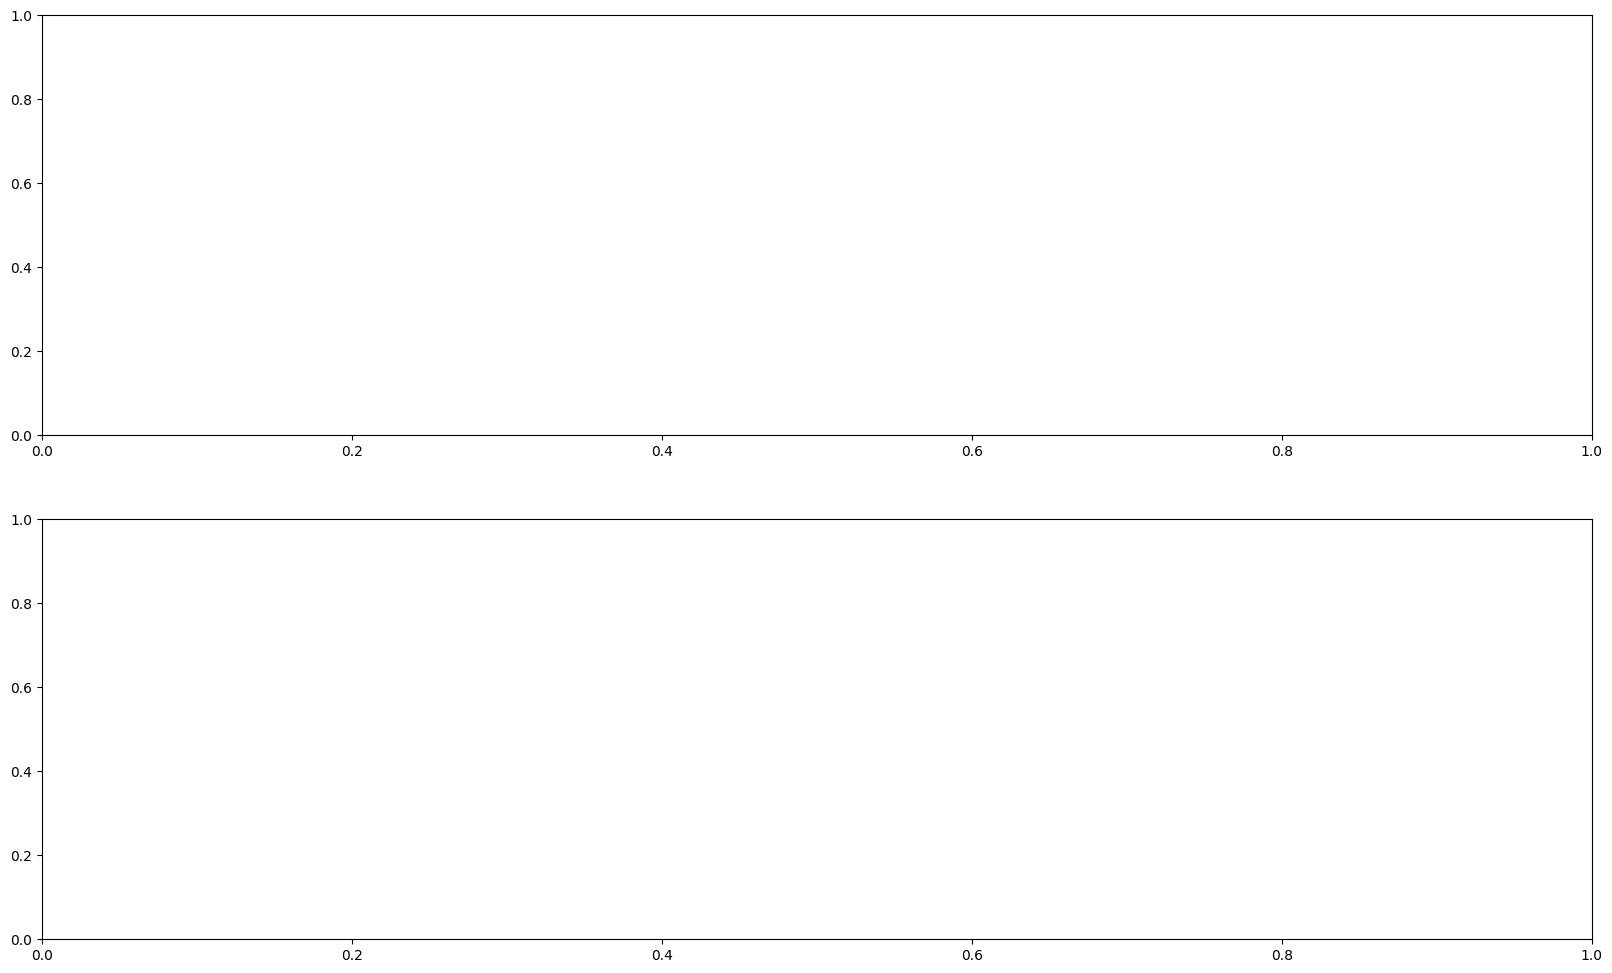

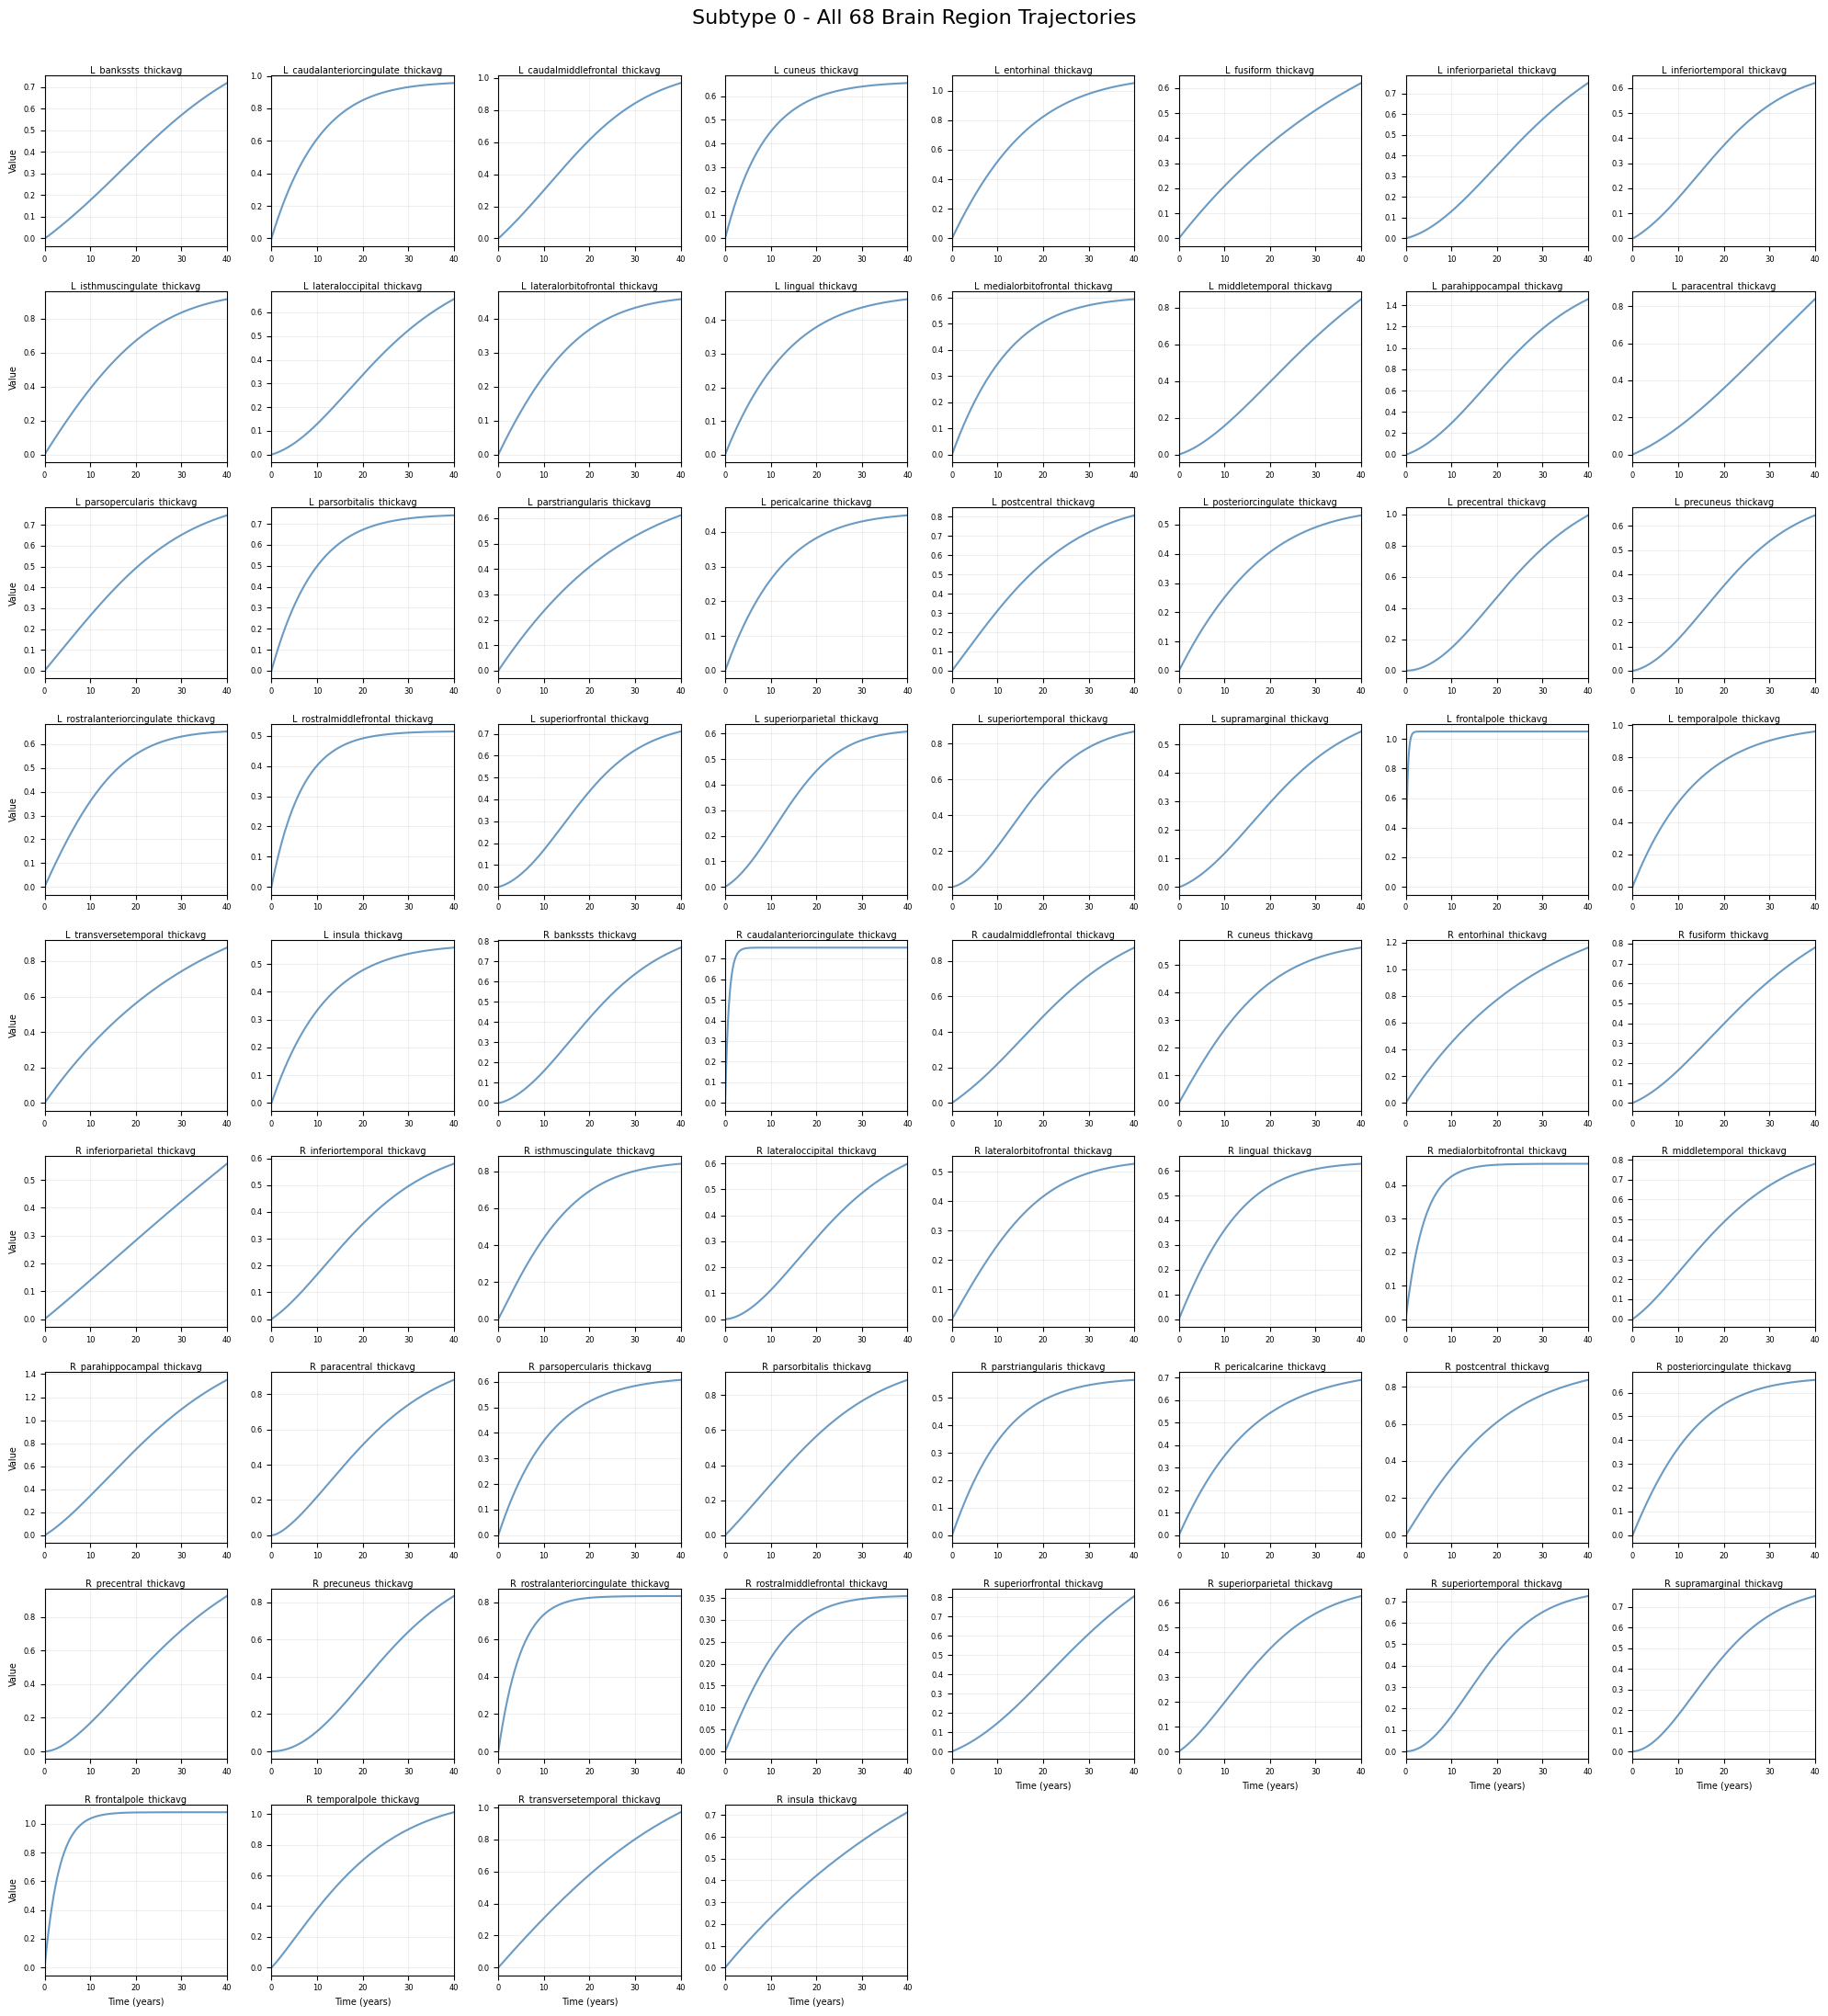

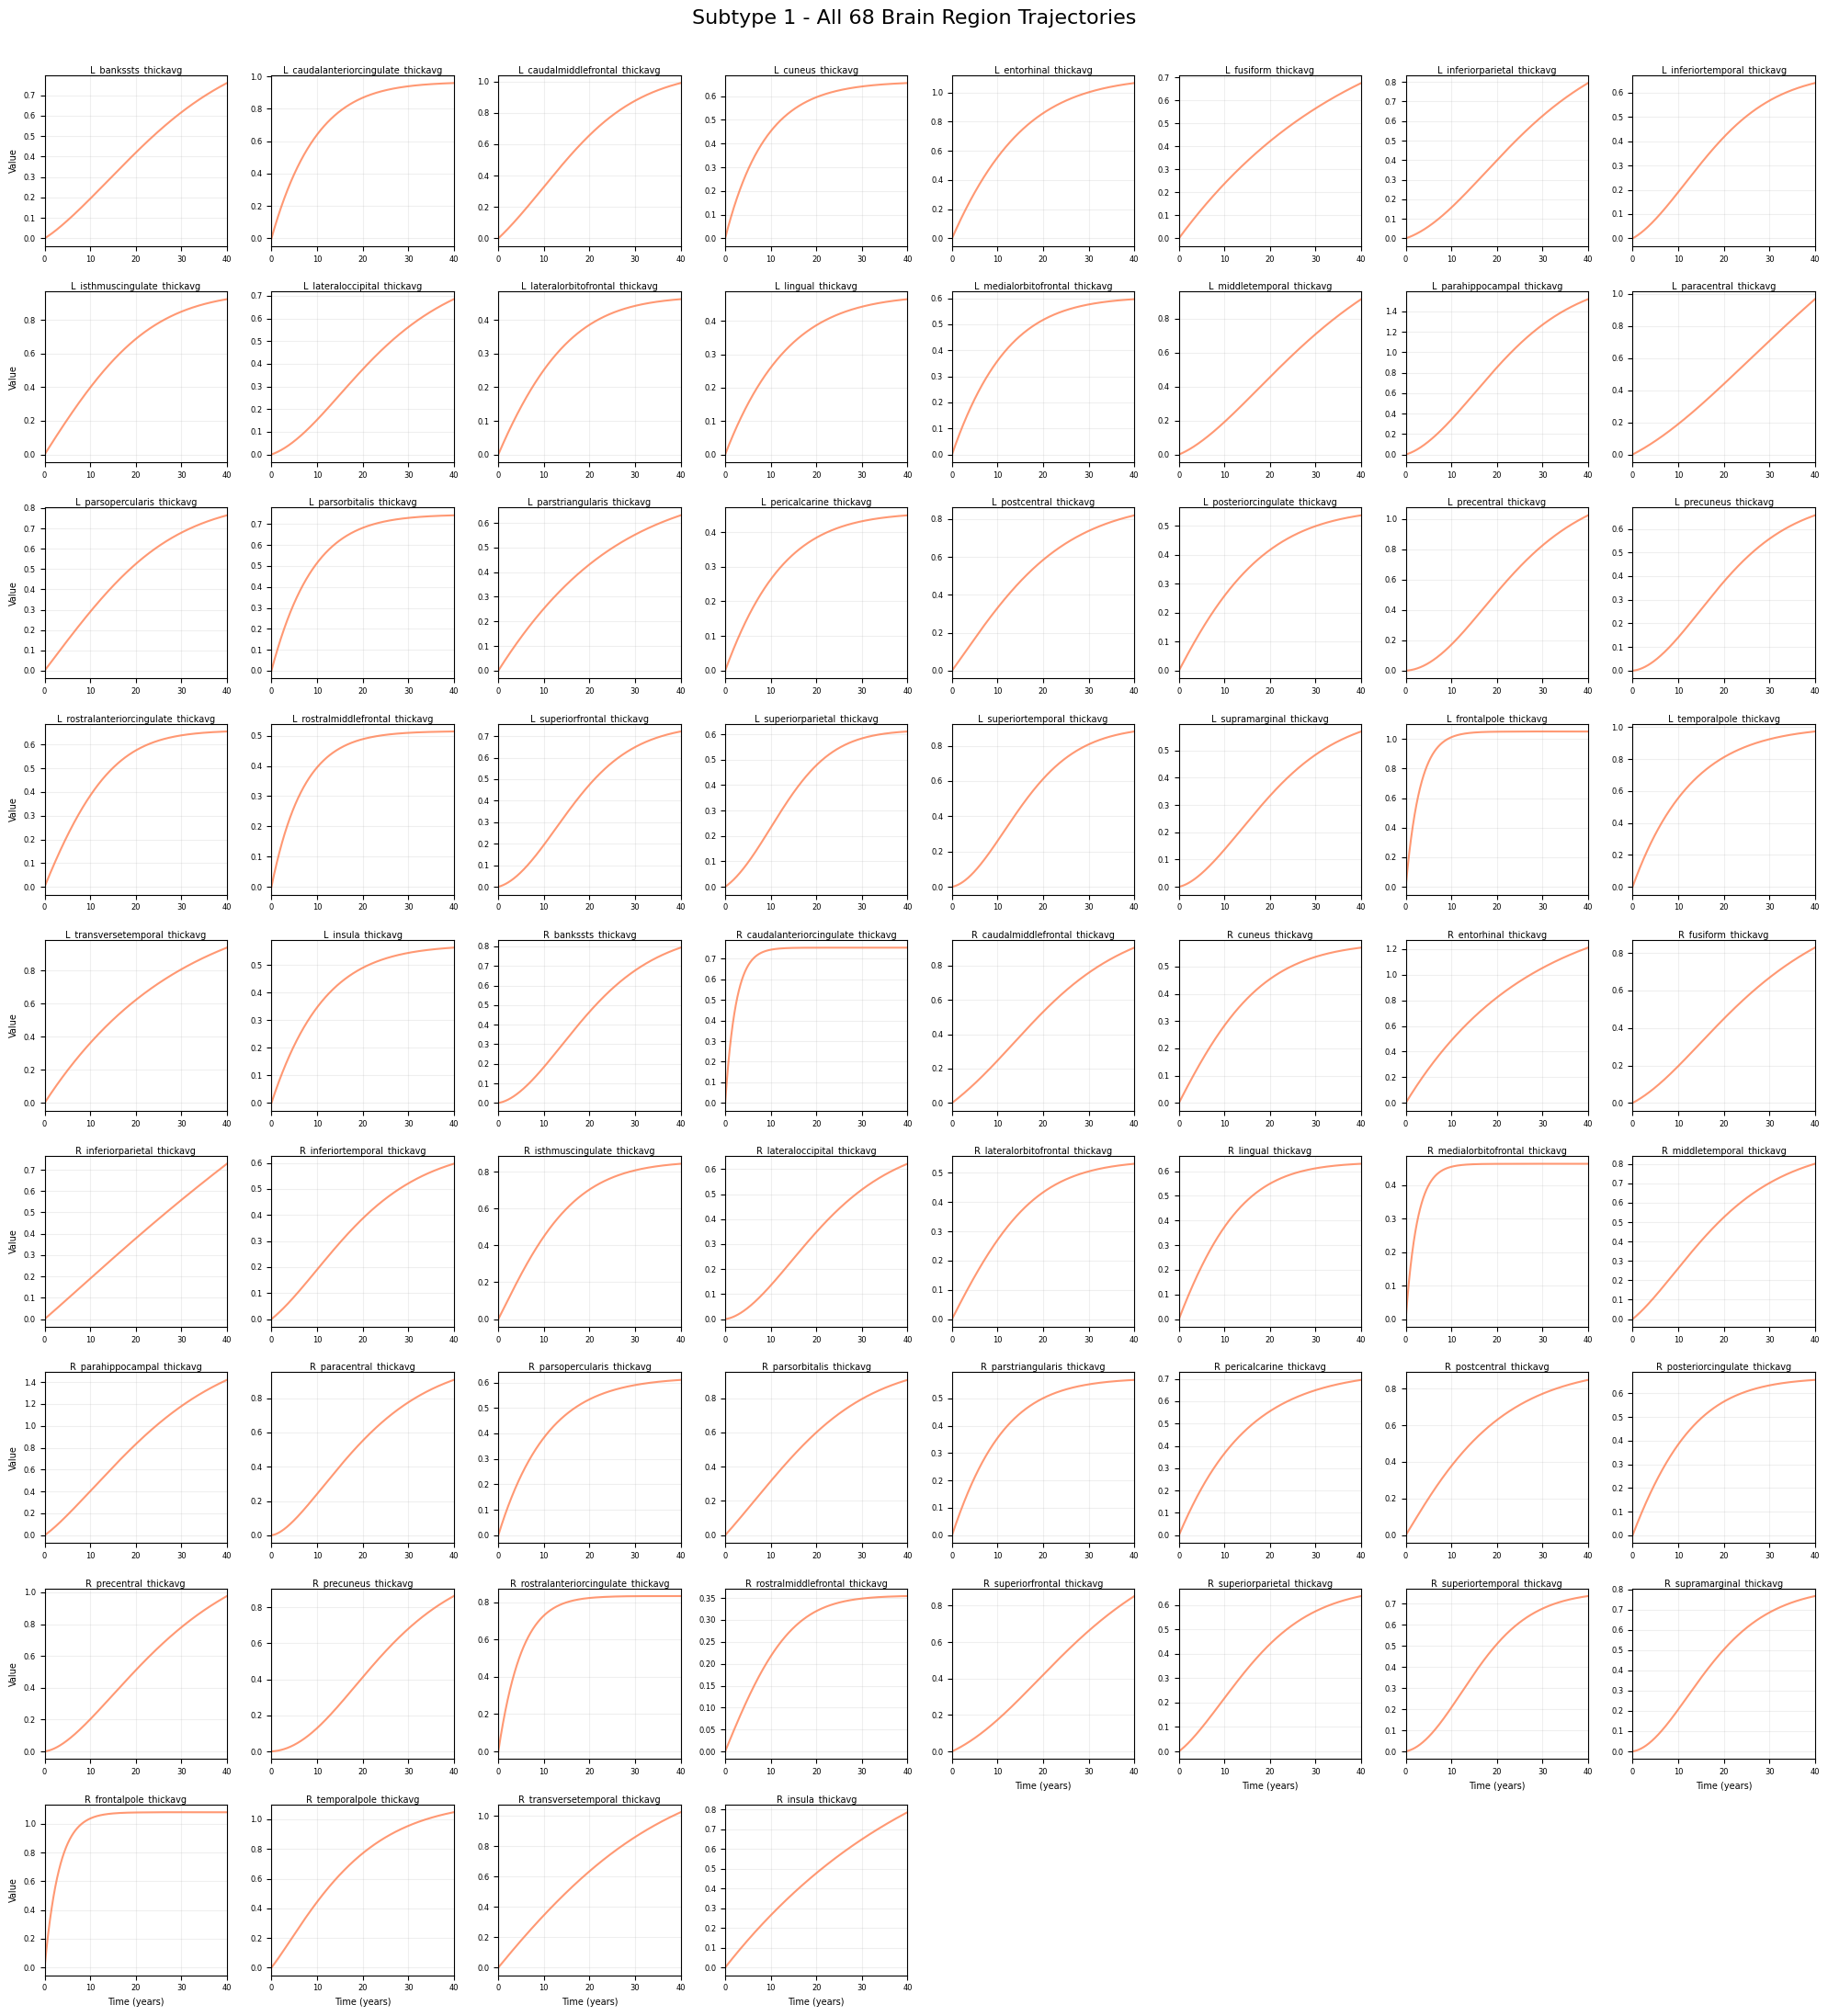

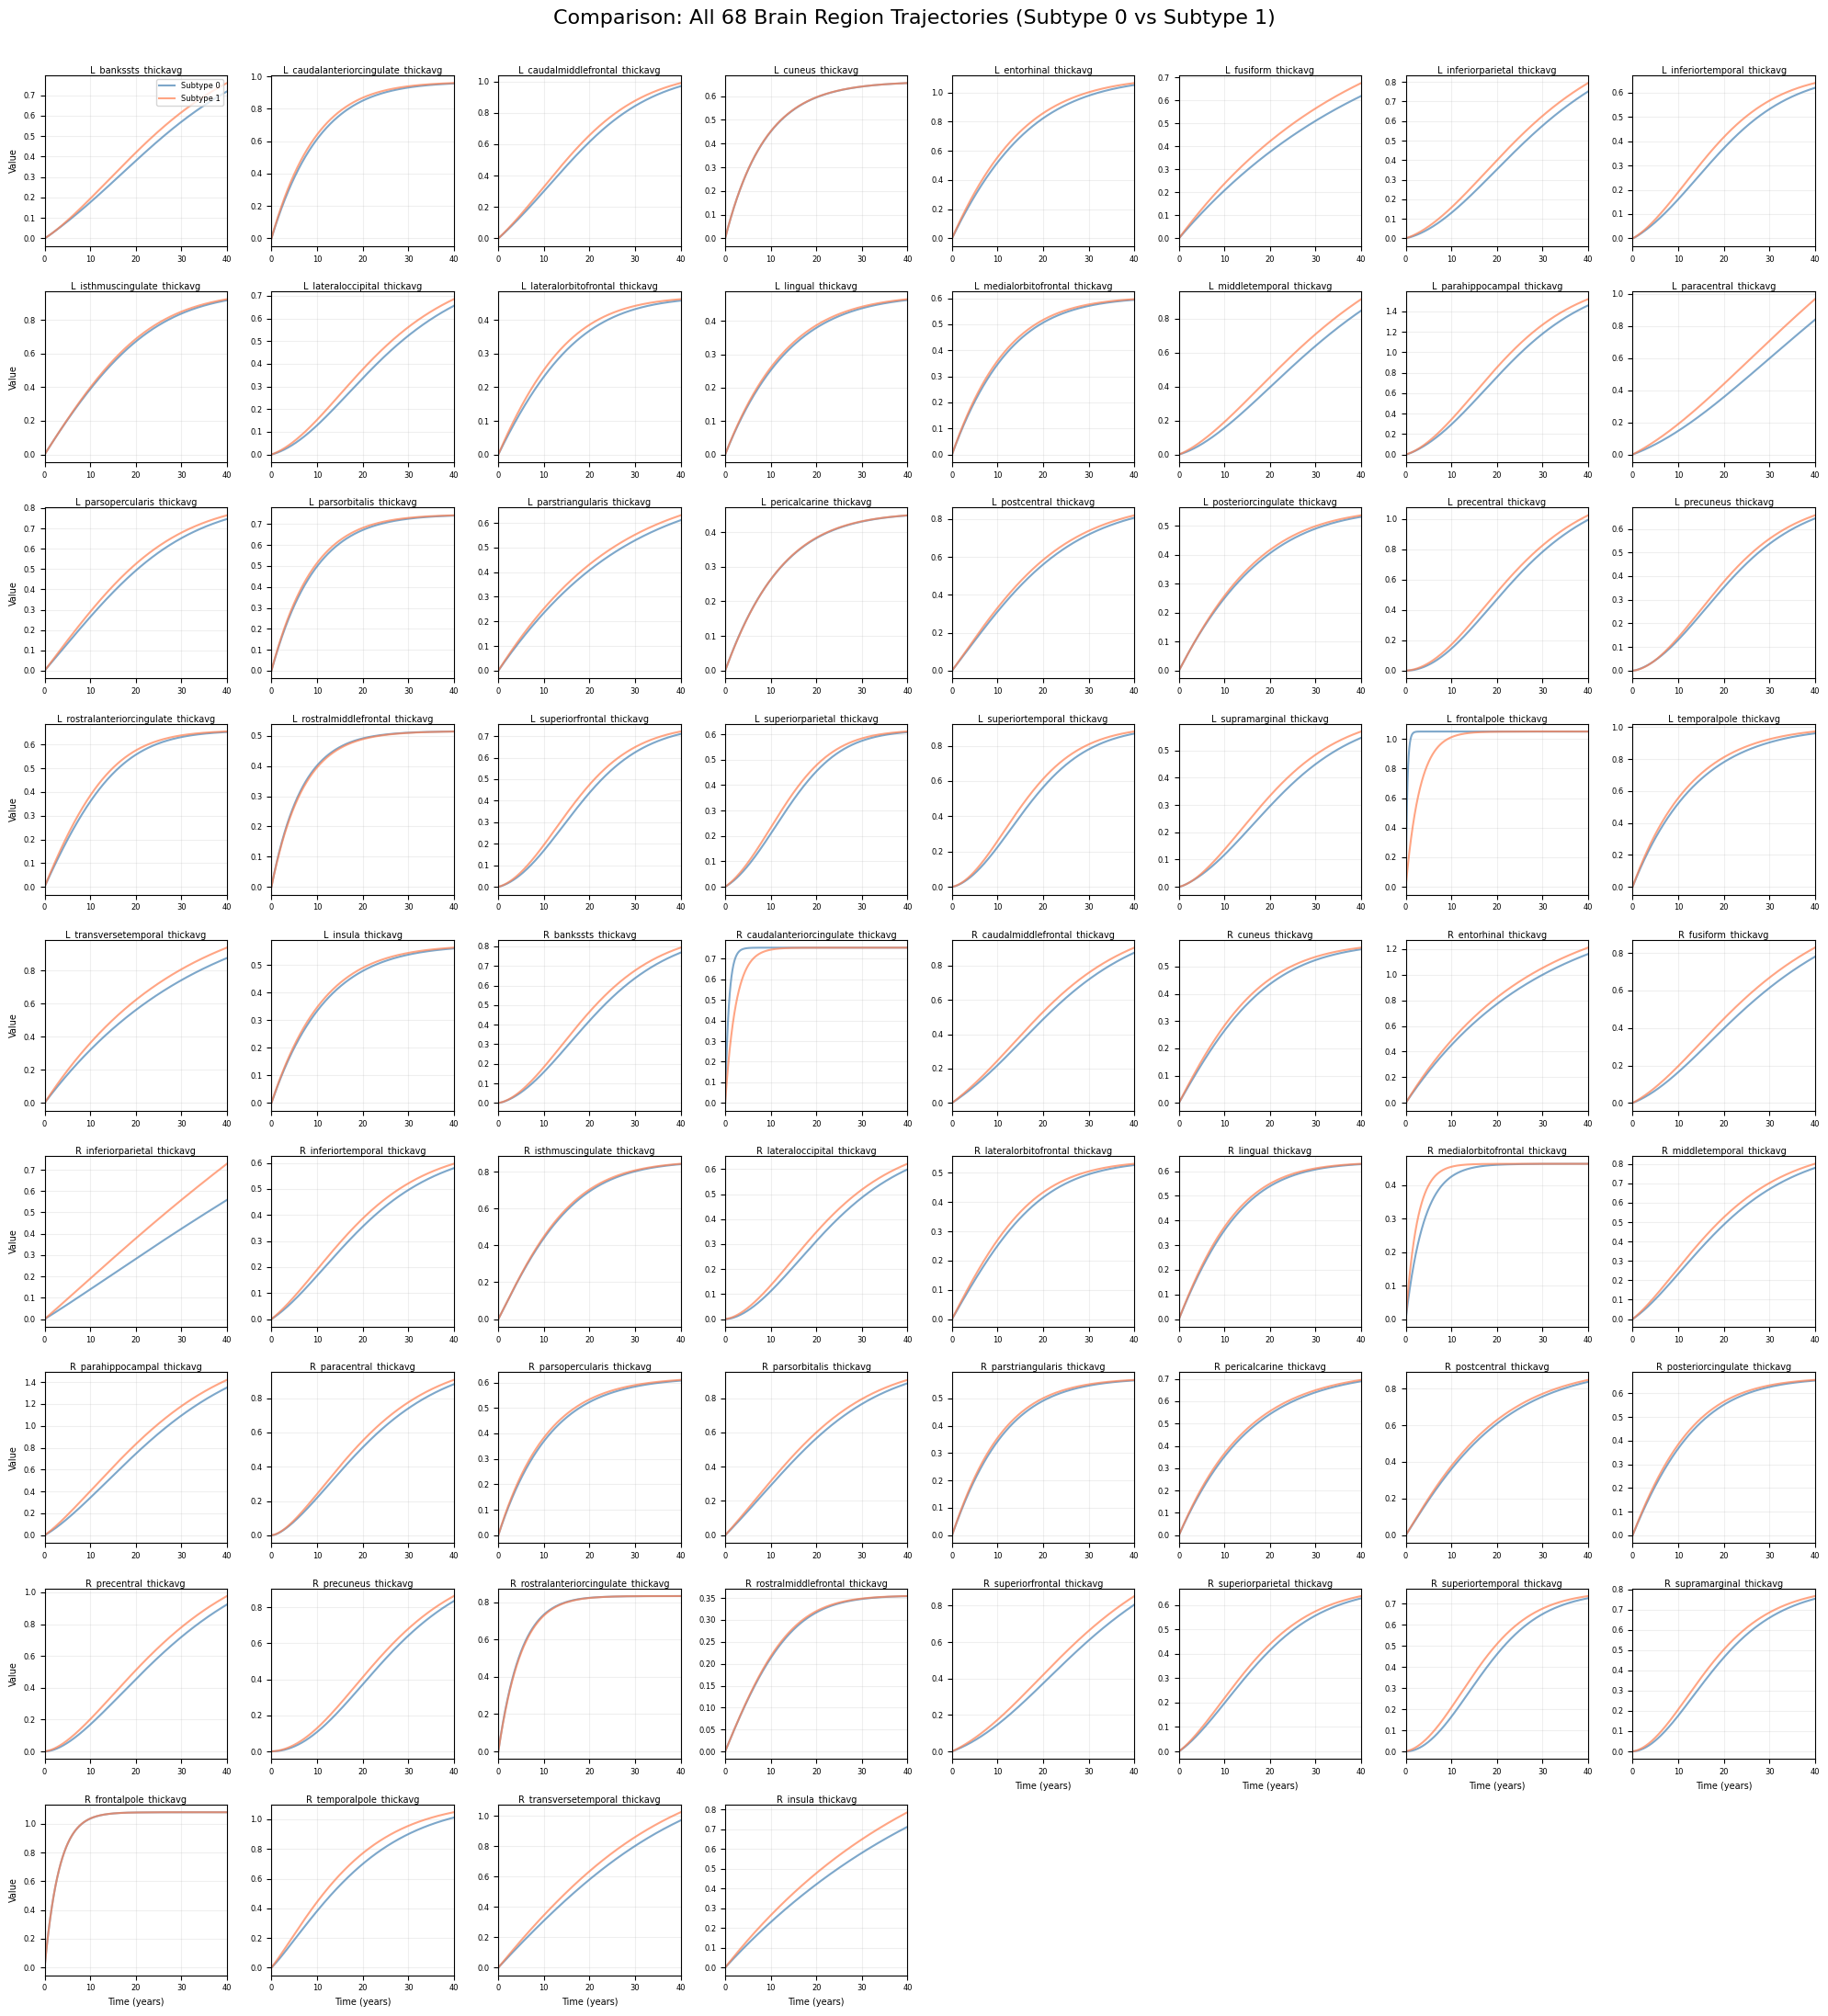

In [19]:
# Plot all 68 brain regions for both subtypes
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Get biomarker names
biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Create a grid layout for all 68 regions
# Use 9 rows x 8 columns = 72 subplots (we'll use 68)
n_rows = 9
n_cols = 8

# Create figure with subplots for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(20, 6*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    # Create a grid of subplots for this subtype
    fig_subtype, axes_grid = plt.subplots(n_rows, n_cols, figsize=(20, 22))
    axes_grid = axes_grid.flatten()
    
    for region_idx in range(n_biomarkers):
        ax = axes_grid[region_idx]
        ax.plot(t_span, Xtraj_subtype[region_idx], linewidth=1.5, alpha=0.8, color='steelblue' if subtype == 0 else 'coral')
        ax.set_title(biomarker_names[region_idx], fontsize=7, pad=2)
        ax.set_xlim(0, t_max)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=6)
        
        # Only show xlabel on bottom row
        if region_idx >= n_biomarkers - n_cols:
            ax.set_xlabel('Time (years)', fontsize=7)
        # Only show ylabel on leftmost column
        if region_idx % n_cols == 0:
            ax.set_ylabel('Value', fontsize=7)
    
    # Hide unused subplots
    for idx in range(n_biomarkers, n_rows * n_cols):
        axes_grid[idx].axis('off')
    
    plt.suptitle(f'Subtype {subtype} - All 68 Brain Region Trajectories', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

# Also create a comparison plot showing both subtypes overlaid for all regions
fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(20, 22))
axes_grid = axes_grid.flatten()

# Compute trajectories for both subtypes
Xtraj_subtype0 = solve_system(np.zeros(n_biomarkers), cluster_f[0], K, t_span, final_scalar_K) * final_s[:, None]
Xtraj_subtype1 = solve_system(np.zeros(n_biomarkers), cluster_f[1], K, t_span, final_scalar_K) * final_s[:, None]

for region_idx in range(n_biomarkers):
    ax = axes_grid[region_idx]
    ax.plot(t_span, Xtraj_subtype0[region_idx], linewidth=1.5, alpha=0.7, color='steelblue', label='Subtype 0')
    ax.plot(t_span, Xtraj_subtype1[region_idx], linewidth=1.5, alpha=0.7, color='coral', label='Subtype 1')
    ax.set_title(biomarker_names[region_idx], fontsize=7, pad=2)
    ax.set_xlim(0, t_max)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=6)
    
    # Only show xlabel on bottom row
    if region_idx >= n_biomarkers - n_cols:
        ax.set_xlabel('Time (years)', fontsize=7)
    # Only show ylabel on leftmost column
    if region_idx % n_cols == 0:
        ax.set_ylabel('Value', fontsize=7)
    
    # Add legend only to first subplot
    if region_idx == 0:
        ax.legend(fontsize=6, loc='upper right')

# Hide unused subplots
for idx in range(n_biomarkers, n_rows * n_cols):
    axes_grid[idx].axis('off')

plt.suptitle('Comparison: All 68 Brain Region Trajectories (Subtype 0 vs Subtype 1)', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()



CONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 5           78
1                                 7           56

Chi-squared = 0.6468
  p-value = 0.4213
  df = 1


<Figure size 1000x600 with 0 Axes>

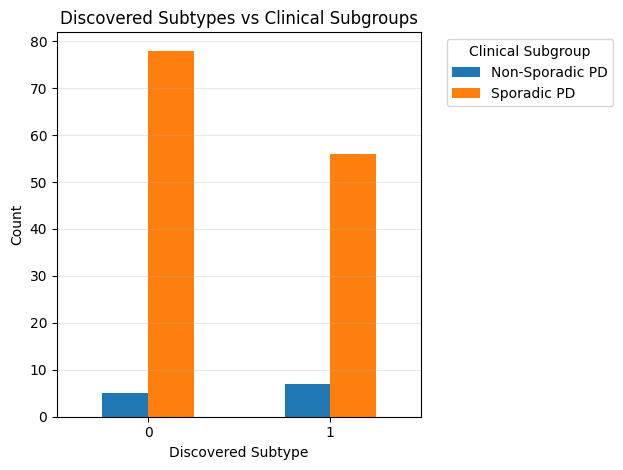

In [20]:
# Clinical Subgroup Comparison: Sporadic PD vs Non-Sporadic PD
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table
contingency = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup, name='Clinical Subgroup')
)
print("\nCONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-squared = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot
plt.figure(figsize=(10, 6))
contingency.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 0 Beta Statistics:
  Mean: 12.8620
  Median: 12.8223
  Std: 0.8970

Subtype 1 Beta Statistics:
  Mean: 15.6428
  Median: 15.6883
  Std: 1.0919


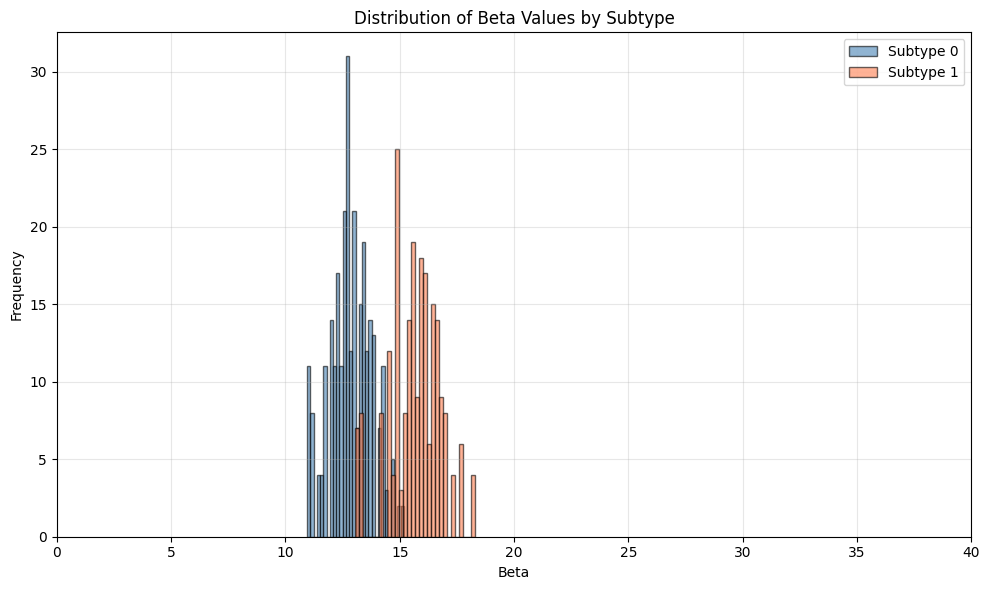

In [21]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")
plt.xlim(0, 40)
plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


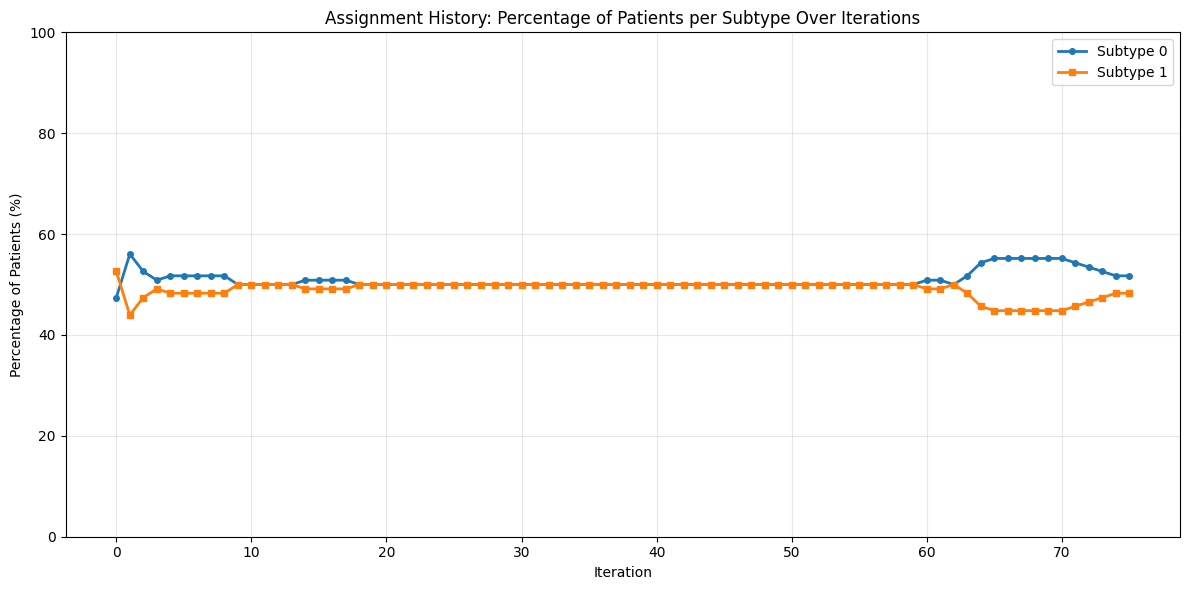


Assignment History Summary:
  Initial - Subtype 0: 47.4%, Subtype 1: 52.6%
  Final   - Subtype 0: 51.7%, Subtype 1: 48.3%
  Change  - Subtype 0: 4.3%, Subtype 1: -4.3%


In [22]:
# Plot assignment history over iterations
if "assignment_history" in best_data.files:
    assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
    n_iterations = assignment_history.shape[1] - 1
    
    # Calculate percentage of subtype 0 and 1 for each iteration
    pct_subtype0 = []
    pct_subtype1 = []
    
    for iter_idx in range(n_iterations + 1):
        assignments_iter = assignment_history[:, iter_idx]
        n_patients = len(assignments_iter)
        n_subtype0 = np.sum(assignments_iter == 0)
        n_subtype1 = np.sum(assignments_iter == 1)
        
        pct_subtype0.append(100 * n_subtype0 / n_patients)
        pct_subtype1.append(100 * n_subtype1 / n_patients)
    
    # Plot
    plt.figure(figsize=(12, 6))
    iterations = np.arange(n_iterations + 1)
    plt.plot(iterations, pct_subtype0, label='Subtype 0', linewidth=2, marker='o', markersize=4)
    plt.plot(iterations, pct_subtype1, label='Subtype 1', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Percentage of Patients (%)')
    plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAssignment History Summary:")
    print(f"  Initial - Subtype 0: {pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[0]:.1f}%")
    print(f"  Final   - Subtype 0: {pct_subtype0[-1]:.1f}%, Subtype 1: {pct_subtype1[-1]:.1f}%")
    print(f"  Change  - Subtype 0: {pct_subtype0[-1] - pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[-1] - pct_subtype1[0]:.1f}%")
else:
    print("Assignment history not available in best_data")


Forcing term comparison across 68 brain regions:
  Subtype 0 - Mean: 0.1037, Std: 0.3695, Range: [0.0000, 2.8638]
  Subtype 1 - Mean: 0.0602, Std: 0.0851, Range: [0.0012, 0.4241]
  Difference - Mean: 0.0435, Std: 0.3206


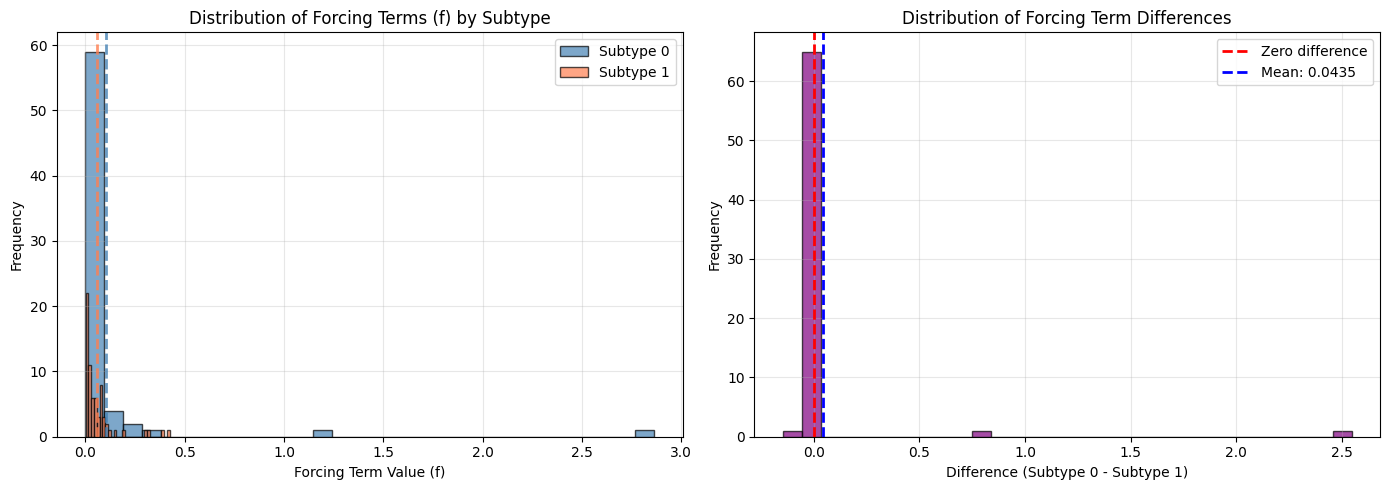

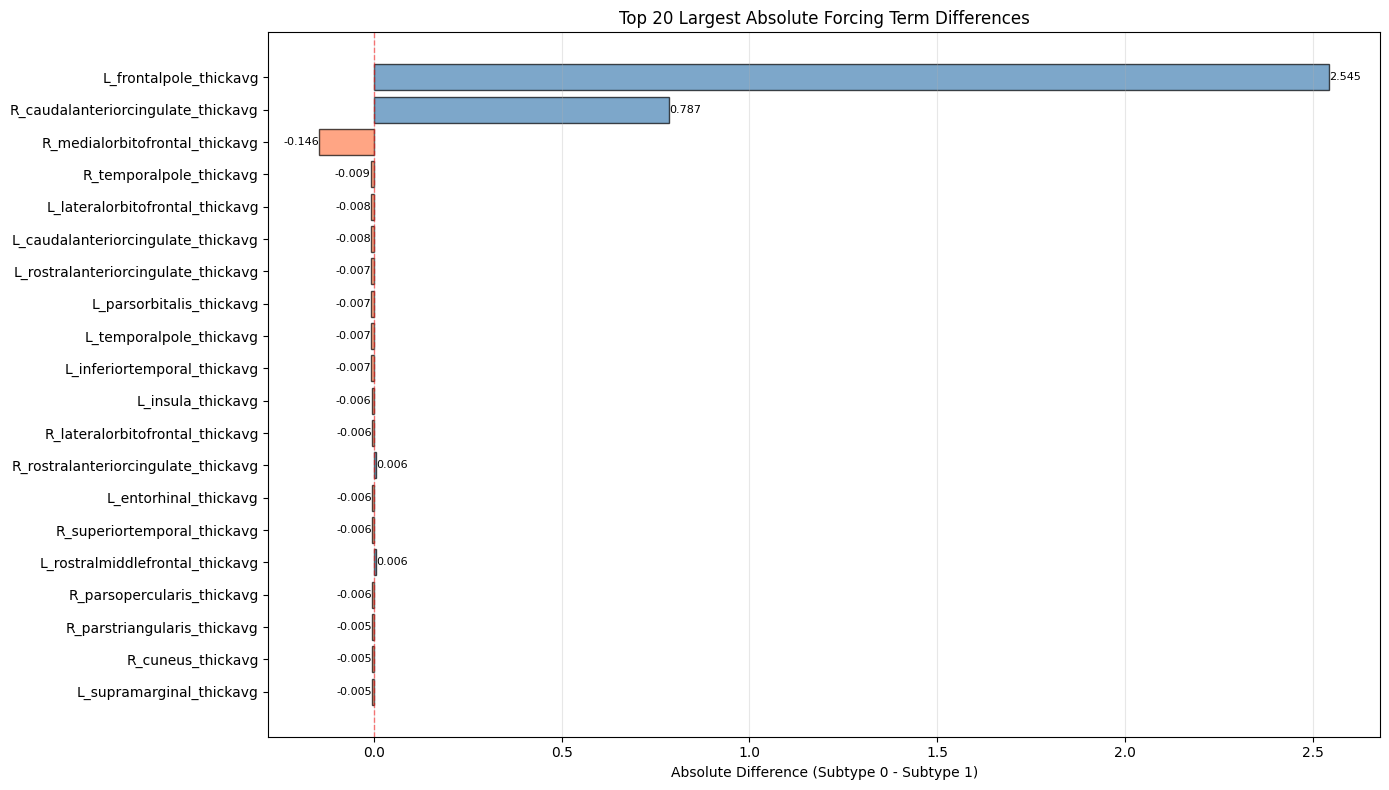


Top 20 regions with largest absolute differences:
  1. L_frontalpole_thickavg: 2.5452 (Subtype 0: 2.8638, Subtype 1: 0.3186)
  2. R_caudalanteriorcingulate_thickavg: 0.7867 (Subtype 0: 1.2108, Subtype 1: 0.4241)
  3. R_medialorbitofrontal_thickavg: -0.1464 (Subtype 0: 0.2461, Subtype 1: 0.3925)
  4. R_temporalpole_thickavg: -0.0089 (Subtype 0: 0.0259, Subtype 1: 0.0348)
  5. L_lateralorbitofrontal_thickavg: -0.0081 (Subtype 0: 0.0593, Subtype 1: 0.0674)
  6. L_caudalanteriorcingulate_thickavg: -0.0076 (Subtype 0: 0.0960, Subtype 1: 0.1036)
  7. L_rostralanteriorcingulate_thickavg: -0.0075 (Subtype 0: 0.0645, Subtype 1: 0.0720)
  8. L_parsorbitalis_thickavg: -0.0073 (Subtype 0: 0.1026, Subtype 1: 0.1099)
  9. L_temporalpole_thickavg: -0.0070 (Subtype 0: 0.0718, Subtype 1: 0.0788)
  10. L_inferiortemporal_thickavg: -0.0069 (Subtype 0: 0.0076, Subtype 1: 0.0145)
  11. L_insula_thickavg: -0.0064 (Subtype 0: 0.0814, Subtype 1: 0.0878)
  12. R_lateralorbitofrontal_thickavg: -0.0060 (Subtype

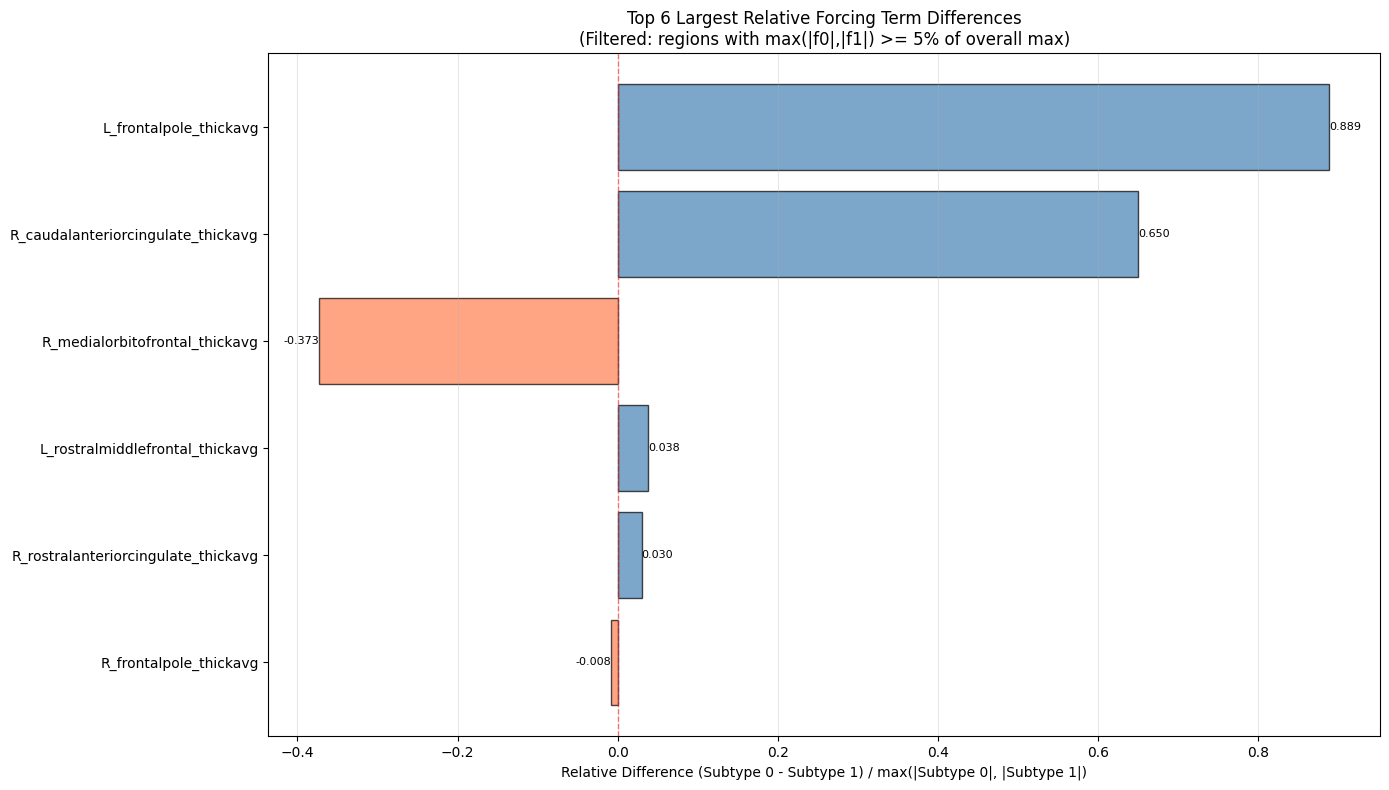


Top 6 regions with largest relative differences (filtered):
  1. L_frontalpole_thickavg:
      Relative diff: 0.8887
      Absolute diff: 2.5452
      Subtype 0: 2.8638, Subtype 1: 0.3186
      Max(|f0|,|f1|): 2.8638
  2. R_caudalanteriorcingulate_thickavg:
      Relative diff: 0.6498
      Absolute diff: 0.7867
      Subtype 0: 1.2108, Subtype 1: 0.4241
      Max(|f0|,|f1|): 1.2108
  3. R_medialorbitofrontal_thickavg:
      Relative diff: -0.3729
      Absolute diff: -0.1464
      Subtype 0: 0.2461, Subtype 1: 0.3925
      Max(|f0|,|f1|): 0.3925
  4. L_rostralmiddlefrontal_thickavg:
      Relative diff: 0.0381
      Absolute diff: 0.0057
      Subtype 0: 0.1489, Subtype 1: 0.1432
      Max(|f0|,|f1|): 0.1489
  5. R_rostralanteriorcingulate_thickavg:
      Relative diff: 0.0299
      Absolute diff: 0.0060
      Subtype 0: 0.2000, Subtype 1: 0.1940
      Max(|f0|,|f1|): 0.2000
  6. R_frontalpole_thickavg:
      Relative diff: -0.0079
      Absolute diff: -0.0024
      Subtype 0: 0.3064

In [23]:
# Compare forcing terms (f) between subtypes for all 68 brain regions
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

f_subtype0 = cluster_f[0]  # (68,)
f_subtype1 = cluster_f[1]  # (68,)

# Get biomarker names
biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

print(f"Forcing term comparison across {n_biomarkers} brain regions:")
print(f"  Subtype 0 - Mean: {np.mean(f_subtype0):.4f}, Std: {np.std(f_subtype0):.4f}, Range: [{np.min(f_subtype0):.4f}, {np.max(f_subtype0):.4f}]")
print(f"  Subtype 1 - Mean: {np.mean(f_subtype1):.4f}, Std: {np.std(f_subtype1):.4f}, Range: [{np.min(f_subtype1):.4f}, {np.max(f_subtype1):.4f}]")
print(f"  Difference - Mean: {np.mean(f_subtype0 - f_subtype1):.4f}, Std: {np.std(f_subtype0 - f_subtype1):.4f}")

# Histogram of both forcing terms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(f_subtype0, bins=30, alpha=0.7, color='steelblue', edgecolor='black', label='Subtype 0')
axes[0].hist(f_subtype1, bins=30, alpha=0.7, color='coral', edgecolor='black', label='Subtype 1')
axes[0].axvline(np.mean(f_subtype0), color='steelblue', linestyle='--', linewidth=2, alpha=0.8)
axes[0].axvline(np.mean(f_subtype1), color='coral', linestyle='--', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Forcing Term Value (f)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Forcing Terms (f) by Subtype')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of differences
f_diff = f_subtype0 - f_subtype1
axes[1].hist(f_diff, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
axes[1].axvline(np.mean(f_diff), color='blue', linestyle='--', linewidth=2, label=f'Mean: {np.mean(f_diff):.4f}')
axes[1].set_xlabel('Difference (Subtype 0 - Subtype 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Forcing Term Differences')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bar chart showing biggest absolute differences
f_diff_abs = np.abs(f_diff)
top_n = 20  # Show top 20 biggest differences
top_indices = np.argsort(f_diff_abs)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(top_indices))
colors_bar = ['steelblue' if f_diff[idx] > 0 else 'coral' for idx in top_indices]
bars = ax.barh(x_pos, f_diff[top_indices], color=colors_bar, alpha=0.7, edgecolor='black')

ax.set_yticks(x_pos)
ax.set_yticklabels([biomarker_names[idx] for idx in top_indices])
ax.set_xlabel('Absolute Difference (Subtype 0 - Subtype 1)')
ax.set_title(f'Top {top_n} Largest Absolute Forcing Term Differences')
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()  # Show largest differences at top

# Add value labels on bars
for i, (idx, bar) in enumerate(zip(top_indices, bars)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left' if width > 0 else 'right', 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop {top_n} regions with largest absolute differences:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {biomarker_names[idx]}: {f_diff[idx]:.4f} (Subtype 0: {f_subtype0[idx]:.4f}, Subtype 1: {f_subtype1[idx]:.4f})")

# Calculate relative differences and filter by magnitude threshold
# Relative difference: (f0 - f1) / max(|f0|, |f1|)
max_abs_per_region = np.maximum(np.abs(f_subtype0), np.abs(f_subtype1))
overall_max_abs = np.max(max_abs_per_region)

# Calculate relative differences (handle division by zero)
relative_diff = np.zeros(n_biomarkers)
for i in range(n_biomarkers):
    max_abs_i = max_abs_per_region[i]
    if max_abs_i > 1e-10:  # Avoid division by zero
        relative_diff[i] = f_diff[i] / max_abs_i
    else:
        relative_diff[i] = 0.0

# Filter threshold: only show regions where max(|f0|, |f1|) >= threshold * overall_max
threshold_fraction = 0.05  # 5% of overall max
threshold_value = threshold_fraction * overall_max_abs
valid_mask = max_abs_per_region >= threshold_value
valid_indices = np.where(valid_mask)[0]

print(f"\n=== Relative Difference Analysis ===")
print(f"Overall max absolute forcing term: {overall_max_abs:.4f}")
print(f"Threshold (5% of max): {threshold_value:.4f}")
print(f"Regions above threshold: {len(valid_indices)}/{n_biomarkers}")

# Bar chart showing relative differences for filtered regions
relative_diff_filtered = relative_diff[valid_indices]
relative_diff_abs_filtered = np.abs(relative_diff_filtered)
top_n_rel = min(20, len(valid_indices))  # Show top 20 or all if fewer
top_indices_rel = np.argsort(relative_diff_abs_filtered)[-top_n_rel:][::-1]
top_indices_rel_original = valid_indices[top_indices_rel]

fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(top_indices_rel_original))
colors_bar_rel = ['steelblue' if relative_diff[idx] > 0 else 'coral' for idx in top_indices_rel_original]
bars = ax.barh(x_pos, relative_diff[top_indices_rel_original], color=colors_bar_rel, alpha=0.7, edgecolor='black')

ax.set_yticks(x_pos)
ax.set_yticklabels([biomarker_names[idx] for idx in top_indices_rel_original])
ax.set_xlabel('Relative Difference (Subtype 0 - Subtype 1) / max(|Subtype 0|, |Subtype 1|)')
ax.set_title(f'Top {top_n_rel} Largest Relative Forcing Term Differences\n(Filtered: regions with max(|f0|,|f1|) >= {threshold_fraction*100:.0f}% of overall max)')
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()  # Show largest differences at top

# Add value labels on bars
for i, (idx, bar) in enumerate(zip(top_indices_rel_original, bars)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left' if width > 0 else 'right', 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop {top_n_rel} regions with largest relative differences (filtered):")
for i, idx in enumerate(top_indices_rel_original):
    max_abs_i = max_abs_per_region[idx]
    rel_diff_i = relative_diff[idx]
    print(f"  {i+1}. {biomarker_names[idx]}:")
    print(f"      Relative diff: {rel_diff_i:.4f}")
    print(f"      Absolute diff: {f_diff[idx]:.4f}")
    print(f"      Subtype 0: {f_subtype0[idx]:.4f}, Subtype 1: {f_subtype1[idx]:.4f}")
    print(f"      Max(|f0|,|f1|): {max_abs_i:.4f}")


In [24]:
top10_df = summary_df.head(10)
display_cols = ["candidate", "final_lse", "scalar_K", "mean_s", "subtype0_count", "subtype1_count"]
if all(col in top10_df.columns for col in display_cols):
    print(top10_df[display_cols].to_string(index=False))
else:
    print(top10_df)


candidate  final_lse             scalar_K   mean_s  subtype0_count  subtype1_count
      103 611.743849  0.04325942507541538 0.949596              60              56
       23 694.417638 0.030131337810075296 0.907538              65              51
        3 699.863852 0.037723024643891365 0.924450              65              51
        7 703.962317  0.03673380232781289 0.929452              63              53
       11 707.294226 0.018134616890483776 0.850091              63              53
        0 720.967400  0.13590192707502136 0.497770              65              51
        5 722.113326  0.13336706490728228 0.498595              65              51
        9 722.302897  0.13256054764192648 0.498473              65              51
       50 723.562684  0.14310095798749373 0.498293              65              51
       12 726.570777   0.1451979842385529 0.494489              63              53
